In [36]:
import pandas as pd 
import numpy as np
df = pd.read_csv(r"E:\Pyhton code\Data Sets\archive\credit card fraud detection\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [37]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [38]:
# Log transform
df["log_amount"] = np.log1p(df["Amount"])

# Time → hour
df["hour"] = (df["Time"] // 3600) % 24

# Deviation
# df["amount_dev"] = df["Amount"] - df["Amount"].mean()

In [39]:
#Split dataset
X = df.drop("Class", axis=1).values
y = df["Class"].values

In [40]:
mean_amount = X[y == 0][:, -1].mean()  # or from train set

df["amount_dev"] = df["Amount"] - mean_amount

In [41]:
x_train = X[y == 0]
x_test = X
y_test = y

In [42]:
#Feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [43]:
import numpy as np
mu = np.mean(x_train_scaled, axis=0)
sigma = np.var(x_train_scaled, axis=0)

In [44]:
#Compute Probabilites
def gaussian_log_prob(X, mu, sigma):
    sigma = np.where(sigma == 0, 1e-6, sigma)
    
    term1 = -0.5 * np.sum(np.log(2 * np.pi * sigma))
    term2 = -0.5 * np.sum(((X - mu) ** 2) / sigma, axis=1)
    
    return term1 + term2

log_p_vals = gaussian_log_prob(x_test_scaled, mu, sigma)

In [45]:
best_f1 = 0
best_thresh = 0

for p in np.linspace(0.01, 1, 50):
    thresh = np.percentile(log_p_vals, p)
    preds_temp = (log_p_vals < thresh).astype(int)
    
    from sklearn.metrics import f1_score
    f1 = f1_score(y_test, preds_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print("Best threshold:", best_thresh)

Best threshold: -843.7383780896504


In [46]:
#Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, preds_temp))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    284315
           1       0.11      0.62      0.18       492

    accuracy                           0.99    284807
   macro avg       0.55      0.80      0.59    284807
weighted avg       1.00      0.99      0.99    284807



In [47]:
#Inspect Detect Frauds
frauds = df[preds_temp==1]
print(frauds.head())

        Time        V1         V2        V3        V4        V5        V6  \
164    103.0 -6.093248 -12.114213 -5.694973  3.294389 -1.413792  4.776000   
362    266.0 -2.564961   2.470985  2.649417 -1.564256  1.794297 -0.614742   
601    454.0 -3.133891   2.887394  2.178690 -1.576535  1.434510 -0.687313   
1158   905.0 -6.169664   6.118940 -1.667775 -1.206991 -0.021373 -1.208458   
1388  1077.0 -3.936794  -3.670519 -1.453820  2.299750 -9.749440  6.456410   

             V7        V8        V9  ...       V24       V25       V26  \
164    4.808426 -0.228197 -0.525896  ...  1.215279 -0.406073 -0.653384   
362    4.185906 -3.855359  5.436633  ...  0.306494  0.226844 -0.365416   
601    3.816056 -3.416915  5.459274  ...  0.302196  0.299993 -0.359155   
1158   2.184989 -1.512188  6.450992  ...  0.413380  0.666632 -0.530568   
1388  10.784088 -2.160016 -0.238116  ...  0.250607  0.300908  1.157867   

           V27       V28   Amount  Class  log_amount  hour   amount_dev  
164  -0.711222  0.

In [48]:
for i in range(len(preds_temp)):
    if preds_temp[i] == 1:
        print(f"""
🚨 FRAUD ALERT
Amount: ₹{df.iloc[i]['Amount']:.2f}
Time: {df.iloc[i]['Time']}
Log Probability: {log_p_vals[i]:.2f}
Risk Level: {"HIGH" if log_p_vals[i] < np.percentile(log_p_vals, 0.1) else "MEDIUM"}
-------------------------
""")


🚨 FRAUD ALERT
Amount: ₹3828.04
Time: 103.0
Log Probability: -297.08
Risk Level: MEDIUM
-------------------------


🚨 FRAUD ALERT
Amount: ₹10.35
Time: 266.0
Log Probability: -177.84
Risk Level: MEDIUM
-------------------------


🚨 FRAUD ALERT
Amount: ₹9.65
Time: 454.0
Log Probability: -173.85
Risk Level: MEDIUM
-------------------------


🚨 FRAUD ALERT
Amount: ₹0.89
Time: 905.0
Log Probability: -191.30
Risk Level: MEDIUM
-------------------------


🚨 FRAUD ALERT
Amount: ₹2452.03
Time: 1077.0
Log Probability: -215.55
Risk Level: MEDIUM
-------------------------


🚨 FRAUD ALERT
Amount: ₹7712.43
Time: 1264.0
Log Probability: -1759.21
Risk Level: HIGH
-------------------------


🚨 FRAUD ALERT
Amount: ₹9.95
Time: 1335.0
Log Probability: -171.82
Risk Level: MEDIUM
-------------------------


🚨 FRAUD ALERT
Amount: ₹11.05
Time: 1435.0
Log Probability: -170.58
Risk Level: MEDIUM
-------------------------


🚨 FRAUD ALERT
Amount: ₹19.69
Time: 1477.0
Log Probability: -179.31
Risk Level: MEDIUM
---

In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=25)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [50]:
print("Explained Variance:", np.sum(pca.explained_variance_ratio_))

Explained Variance: 0.8952331642300984


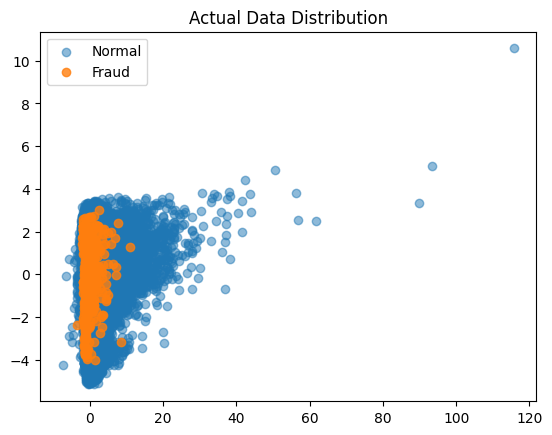

In [51]:
import matplotlib.pyplot as plt

plt.figure()

# Plot normal
plt.scatter(x_test_pca[y_test == 0, 0], x_test_pca[y_test == 0, 1], label="Normal", alpha=0.5)

# Plot fraud
plt.scatter(x_test_pca[y_test == 1, 0], x_test_pca[y_test == 1, 1], label="Fraud", alpha=0.8)

plt.title("Actual Data Distribution")
plt.legend()
plt.show()

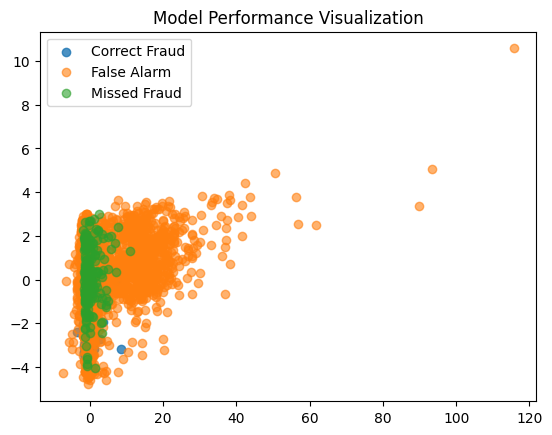

In [52]:
plt.figure()

# True positives (correct fraud)
tp = (preds_temp == 1) & (y_test == 1)

# False positives
fp = (preds_temp == 1) & (y_test == 0)

# False negatives
fn = (preds_temp == 0) & (y_test == 1)

plt.scatter(x_test_pca[tp, 0], x_test_pca[tp, 1], label="Correct Fraud", alpha=0.8)
plt.scatter(x_test_pca[fp, 0], x_test_pca[fp, 1], label="False Alarm", alpha=0.6)
plt.scatter(x_test_pca[fn, 0], x_test_pca[fn, 1], label="Missed Fraud", alpha=0.6)

plt.title("Model Performance Visualization")
plt.legend()
plt.show()

In [53]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.002,  # very low fraud %
    random_state=42
)

model.fit(x_train_scaled)

preds_if = model.predict(x_test_scaled)

# Convert
preds_if = (preds_if == -1).astype(int)

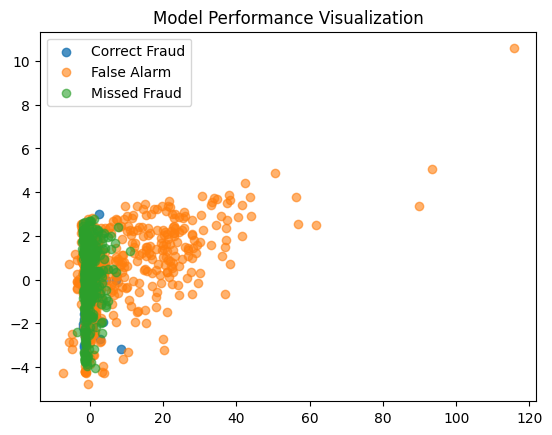

In [54]:
plt.figure()

# True positives (correct fraud)
tp = (preds_if == 1) & (y_test == 1)

# False positives
fp = (preds_if == 1) & (y_test == 0)

# False negatives
fn = (preds_if == 0) & (y_test == 1)

plt.scatter(x_test_pca[tp, 0], x_test_pca[tp, 1], label="Correct Fraud", alpha=0.8)
plt.scatter(x_test_pca[fp, 0], x_test_pca[fp, 1], label="False Alarm", alpha=0.6)
plt.scatter(x_test_pca[fn, 0], x_test_pca[fn, 1], label="Missed Fraud", alpha=0.6)

plt.title("Model Performance Visualization")
plt.legend()
plt.show()

In [55]:
#Evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test, preds_temp))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    284315
           1       0.11      0.62      0.18       492

    accuracy                           0.99    284807
   macro avg       0.55      0.80      0.59    284807
weighted avg       1.00      0.99      0.99    284807



“The model achieves good recall in detecting fraud but suffers from low precision, indicating many false positives. It is suitable as a first-stage anomaly detection system but requires further refinement or combination with supervised models for production use.”

In [56]:
import joblib

# Save model
joblib.dump(model, "isolation_forest_model.pkl")

['isolation_forest_model.pkl']

In [57]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")
joblib.dump(mu, "mu.pkl")
joblib.dump(sigma, "sigma.pkl")

['sigma.pkl']